# Lab 7: Survival Modeling

## Overview
This lab focuses on survival modeling techniques and their applications in statistical analysis. The primary topics covered include Cox regression, regularized Cox regression, Random Survival Forest, Kaplan-Meier curve analysis, and multiple testing correction.

## Topics Covered

### 1. Survival Models
Survival models analyze time-to-event data, allowing us to estimate hazard rates and survival probabilities. Below are the key models explored:

| Model                      | Description |
|----------------------------|-------------|
| **Cox Regression**         | A semi-parametric model that estimates the hazard ratio while accounting for covariates. |
| **Regularized Cox Regression** | A variant of Cox regression incorporating LASSO or Ridge penalties to handle high-dimensional data. |
| **Random Survival Forest** | A non-parametric ensemble learning method that uses decision trees to model survival data. |

#### Implementation Notes
- Cox regression: Implemented using `lifelines` or `statsmodels` in Python.
- Regularized Cox regression: Uses L1/L2 penalties with `scikit-survival` or `sksurv`.
- Random Survival Forest: Implemented via `scikit-survival` or `sksurv` with hyperparameter tuning.

### 2. Kaplan-Meier Curve Analysis
The Kaplan-Meier estimator is a non-parametric method for estimating survival probabilities over time.

<img src="km-curve.png" alt="drawing" style="width:600px;"/>

| Feature                | Description |
|------------------------|-------------|
| **Survival Function**  | Estimates the probability of survival beyond a certain time point. |
| **Log-Rank Test**      | Compares survival distributions across groups. |
| **Visualization**      | Stepwise function plotted using `matplotlib` or `lifelines`. |

#### Interpretation
- A steep drop in the Kaplan-Meier curve suggests high event occurrence at that time point.
- Log-rank test helps assess statistical differences between survival curves of different groups.

### 3. Dataset Usage
While we have skeleton code in the notebook using pre-loaded datasets from `lifelines` and `sksurv` packages, we will also explore a publicly available dataset from [NSCLC Radiogenomics](https://www.cancerimagingarchive.net/collection/nsclc-radiogenomics/). This dataset provides imaging and clinical data for non-small cell lung cancer (NSCLC) patients, allowing us to apply survival analysis techniques in a real-world context.


## Summary
- **Cox models** estimate hazard ratios for covariates.
- **Kaplan-Meier curves** visualize survival probabilities over time.
- **Real-world dataset** from NSCLC Radiogenomics allows practical application of survival modeling.

Each section includes hands-on coding exercises and questions for deeper exploration.


## 1. Survival Models

### 1.1 Cox Regression

We will start by implementing Cox regression for survival analysis. We will also explore different parameters and visualize the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

In [2]:
load_rossi?

Signature: load_rossi(**kwargs)
Docstring:
This data set is originally from Rossi et al. (1980), and is used as an example in Allison (1995). The data pertain to 432 convicts who were released from Maryland state prisons in the 1970s and who were followed up for one year after release. Half the released convicts were assigned at random to an experimental treatment in which they were given financial aid; half did not receive aid.::


    Size: (432,9)
    Example:
        week      20
        arrest     1
        fin        0
        age       27
        race       1
        wexp       0
        mar        0
        paro       1
        prio       3

References
----------
Rossi, P.H., R.A. Berk, and K.J. Lenihan (1980). Money, Work, and Crime:     Some Experimental Results. New York: Academic Press.     John Fox, Marilia Sa Carvalho (2012). The RcmdrPlugin.survival Package: Extending the R Commander Interface to Survival Analysis. Journal of Statistical Software, 49(7), 1-32.
File:     

In [3]:
CoxPHFitter?

Init signature:
CoxPHFitter(
    baseline_estimation_method: 'str' = 'breslow',
    penalizer: 'Union[float, np.ndarray]' = 0.0,
    strata: 'Optional[Union[List[str], str]]' = None,
    l1_ratio: 'float' = 0.0,
    n_baseline_knots: 'Optional[int]' = None,
    knots: 'Optional[List]' = None,
    breakpoints: 'Optional[List]' = None,
    **kwargs,
) -> 'None'
Docstring:     
This class implements fitting Cox's proportional hazard model.

.. math::  h(t|x) = h_0(t) \exp((x - \overline{x})' \beta)

The baseline hazard, :math:`h_0(t)` can be modeled in two ways:

1. (default) non-parametrically, using Breslow's method. In this case, the entire model is the traditional semi-parametric Cox model. Ties are
handled using Efron's method.

2. parametrically, using a pre-specified number of cubic splines, or piecewise values.

This is specified using the ``baseline_estimation_method`` parameter in the initialization (default = ``"breslow"``)

Parameters
----------

  alpha: float, optional (defa

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2026-03-06 02:06:43 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.75           -0.00                0.47                1.00
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.37      0.31           -0.29            0.92                0.75                2.50
wexp      -0.15      0.86      0.21           -0.57            0.27                0.57                1.30
mar       -0.43      0.65      0.38           -1.18            0.31                0.31                1.37
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.10      0.03            0.04            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.98   0.05      4.40
age          0.00 -2.61   0.01      6.79
race         0.00  1.02   0.31      1.70
wexp         0.00 -0.71   0.48      1.06
mar          0.00 -1.14   0.26      1.97
paro         0.00 -0.43   0.66      0.59
prio         0.00  3.19 <0.005      9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37

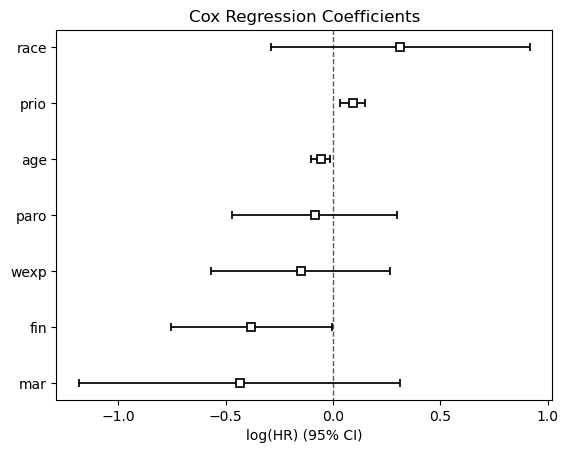

In [4]:
# Load the Rossi dataset
data = load_rossi()

# Fit the Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(data, duration_col='week', event_col='arrest')

# Print the summary of the model
cph.print_summary()

# Plot the coefficients
cph.plot()
plt.title('Cox Regression Coefficients')
plt.show()


In [5]:
CoxPHFitter?
# load_rossi?

Init signature:
CoxPHFitter(
    baseline_estimation_method: 'str' = 'breslow',
    penalizer: 'Union[float, np.ndarray]' = 0.0,
    strata: 'Optional[Union[List[str], str]]' = None,
    l1_ratio: 'float' = 0.0,
    n_baseline_knots: 'Optional[int]' = None,
    knots: 'Optional[List]' = None,
    breakpoints: 'Optional[List]' = None,
    **kwargs,
) -> 'None'
Docstring:     
This class implements fitting Cox's proportional hazard model.

.. math::  h(t|x) = h_0(t) \exp((x - \overline{x})' \beta)

The baseline hazard, :math:`h_0(t)` can be modeled in two ways:

1. (default) non-parametrically, using Breslow's method. In this case, the entire model is the traditional semi-parametric Cox model. Ties are
handled using Efron's method.

2. parametrically, using a pre-specified number of cubic splines, or piecewise values.

This is specified using the ``baseline_estimation_method`` parameter in the initialization (default = ``"breslow"``)

Parameters
----------

  alpha: float, optional (defa

### Questions for Exploration

1. How do we interpret the hazard ratios derived from the Cox model, and what do they imply about risk factors?
2. What assumptions does the Cox proportional hazards model make, and how can we test if they hold? HINT: check this [link](https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html).
3. What happens to the model performance if you include or exclude certain covariates?
4. What happens to the model performance if you change the `baseline_estimation_method`?

### 1.2 Lasso for Censored Data

Now, we will implement Lasso for censored data using the Cox regression model with L1 regularization. We will also explore different parameters and visualize the results.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.linear_model import CoxnetSurvivalAnalysis
from lifelines.datasets import load_rossi
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored

In [7]:
CoxnetSurvivalAnalysis?

Init signature:
CoxnetSurvivalAnalysis(
    *,
    n_alphas=100,
    alphas=None,
    alpha_min_ratio='auto',
    l1_ratio=0.5,
    penalty_factor=None,
    normalize=False,
    copy_X=True,
    tol=1e-07,
    max_iter=100000,
    verbose=False,
    fit_baseline_model=False,
)
Docstring:     
Cox's proportional hazard's model with elastic net penalty.

See the :ref:`User Guide </user_guide/coxnet.ipynb>` and [1]_ for further description.

Parameters
----------
n_alphas : int, optional, default: 100
    Number of alphas along the regularization path.

alphas : array-like or None, optional
    List of alphas where to compute the models.
    If ``None``, alphas are set automatically.

    In this case, the ``alphas`` sequence is determined by :math:`\alpha_\max`
    and ``alpha_min_ratio``. The latter determines the smallest alpha value
    :math:`\alpha_\min` in the generated alphas sequence such that
    ``alpha_min_ratio`` equals the ratio :math:`\frac{\alpha_\min}{\alpha_\max}`.
    T

In [8]:
concordance_index_censored?

Signature:
concordance_index_censored(
    event_indicator,
    event_time,
    estimate,
    tied_tol=1e-08,
)
Docstring:
Measures the agreement between a predicted risk score and the actual time-to-event.

The concordance index is a measure of rank correlation between predicted risk
scores and observed time points. It is defined as the proportion of all comparable
pairs in which the predictions and outcomes are concordant.
A pair of samples is concordant if the sample with a higher risk score has a
shorter time-to-event. A higher concordance index indicates better model performance.

A pair of samples is considered comparable if the sample with a shorter
survival time experienced an event. This means we can confidently say that
the individual with the shorter time had a worse outcome. If both samples
are censored, or if they experienced an event at the same time, they are
not comparable.

When predicted risks are identical for a pair, 0.5 rather than 1 is added to the count
of concor

In [9]:
# Load the Rossi dataset
data = load_rossi()

# Prepare the data for sksurv
X = data.drop(columns=['week', 'arrest']).astype(float)
y = np.array([(bool(event), time) for event, time in zip(data['arrest'], data['week'])], dtype=[('event', bool), ('time', float)])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Cox proportional hazards model with L1 regularization
cph_lasso = CoxnetSurvivalAnalysis(l1_ratio=0.5)
cph_lasso.fit(X_train, y_train)

# Predict the risk scores on the test set
risk_scores = cph_lasso.predict(X_test)

# Calculate the concordance index
c_index = concordance_index_censored(y_test['event'], y_test['time'], risk_scores)[0]
print(f'Concordance Index: {c_index:.4f}')


Concordance Index: 0.6631


### Questions for Exploration

1. How does the L1 regularization affect the coefficients of the Cox regression model? HINT: examine `cph_lasso.coef_`.
2. How does penalizing the Cox model (e.g., L1/L2 regularization) impact variable selection and model performance?
3. What happens to the model performance if you change the `l1_ratio`?
4. What are the differences in model performance and interpretability between `CoxPHFitter` from `lifelines` and `CoxnetSurvivalAnalysis` from `sksurv`?

### 1.3 Random Survival Forest

Next, we will implement a Random Survival Forest for survival analysis. We will also explore different parameters and visualize the results.

In [10]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.datasets import load_whas500
from sksurv.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

In [11]:
permutation_importance?

Signature:
permutation_importance(
    estimator,
    X,
    y,
    *,
    scoring=None,
    n_repeats=5,
    n_jobs=None,
    random_state=None,
    sample_weight=None,
    max_samples=1.0,
)
Docstring:
Permutation importance for feature evaluation [BRE]_.

The :term:`estimator` is required to be a fitted estimator. `X` can be the
data set used to train the estimator or a hold-out set. The permutation
importance of a feature is calculated as follows. First, a baseline metric,
defined by :term:`scoring`, is evaluated on a (potentially different)
dataset defined by the `X`. Next, a feature column from the validation set
is permuted and the metric is evaluated again. The permutation importance
is defined to be the difference between the baseline metric and metric from
permutating the feature column.

Read more in the :ref:`User Guide <permutation_importance>`.

Parameters
----------
estimator : object
    An estimator that has already been :term:`fitted` and is compatible
    with :term:

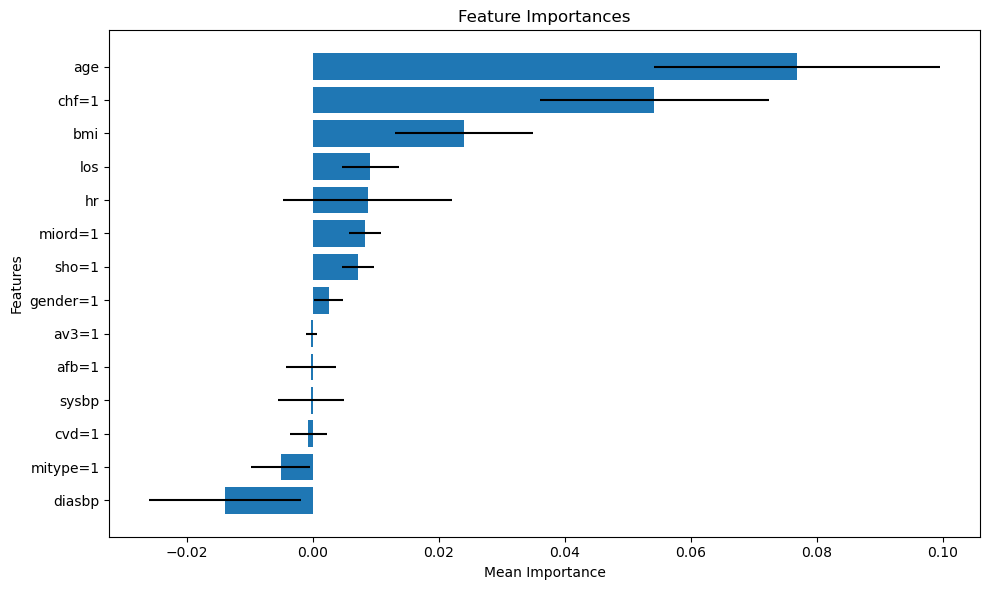

In [12]:
# Load the WHAS500 dataset
data_x, data_y = load_whas500()

# Encode categorical variables
encoder = OneHotEncoder()
data_x = encoder.fit_transform(data_x)

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.2, random_state=42)

# Train a Random Survival Forest model
rsf = RandomSurvivalForest(n_estimators=100, random_state=42)
rsf.fit(X_train, y_train)

# please refer to https://scikit-survival.readthedocs.io/en/stable/user_guide/random-survival-forest.html
result = permutation_importance(rsf, X_test, y_test, n_repeats=15, random_state=42)
feature_importance = pd.DataFrame(
         {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=data_x.columns,
).sort_values(by="importances_mean", ascending=False)

# Sort by importances_mean and plot
feature_importance = feature_importance.sort_values(by="importances_mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(feature_importance.index, feature_importance['importances_mean'], xerr=feature_importance['importances_std'], align='center')
plt.xlabel('Mean Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [13]:
RandomSurvivalForest?
rsf.score(X_test,y_test) # dang (stop it autocorrect)

np.float64(0.7463694697737251)

Init signature:
RandomSurvivalForest(
    n_estimators=100,
    *,
    max_depth=None,
    min_samples_split=6,
    min_samples_leaf=3,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    max_samples=None,
    low_memory=False,
)
Docstring:     
A random survival forest.

A random survival forest is a meta estimator that fits a number of
survival trees on various sub-samples of the dataset and uses
averaging to improve the predictive accuracy and control over-fitting.
The sub-sample size is always the same as the original input sample
size but the samples are drawn with replacement if
`bootstrap=True` (default).

In each survival tree, the quality of a split is measured by the
log-rank splitting rule.

See the :ref:`User Guide </user_guide/random-survival-forest.ipynb>`,
[1]_ and [2]_ for further description.

Parameters
----------
n_

### Questions for Exploration

1. How do the feature importances from the Random Survival Forest model interpret the relationship between covariates and survival time?
2. What happens to the model performance if you change the number of trees (`n_estimators`)?
3. How does the choice of dataset affect the Random Survival Forest results and their interpretation?

## 2. Kaplan-Meier Curve Analysis

We will perform Kaplan-Meier curve analysis to visualize and interpret survival probabilities over time. We will also explore different visualization techniques.

In [14]:
from lifelines import KaplanMeierFitter
KaplanMeierFitter?

Init signature: KaplanMeierFitter(alpha: 'float' = 0.05, label: 'str' = None)
Docstring:     
Class for fitting the Kaplan-Meier estimate for the survival function.

Parameters
----------
alpha: float, optional (default=0.05)
    The alpha value associated with the confidence intervals.
label: string, optional
    Provide a new label for the estimate - useful if looking at many groups.

Examples
--------
.. code:: python

    from lifelines import KaplanMeierFitter
    from lifelines.datasets import load_waltons
    waltons = load_waltons()

    kmf = KaplanMeierFitter(label="waltons_data")
    kmf.fit(waltons['T'], waltons['E'])
    kmf.plot()


Attributes
----------
survival_function_ : DataFrame
    The estimated survival function (with custom timeline if provided)
median_survival_time_ : float
    The estimated median time to event. np.inf if doesn't exist.
confidence_interval_ : DataFrame
    The lower and upper confidence intervals for the survival function. An alias of
    ``con

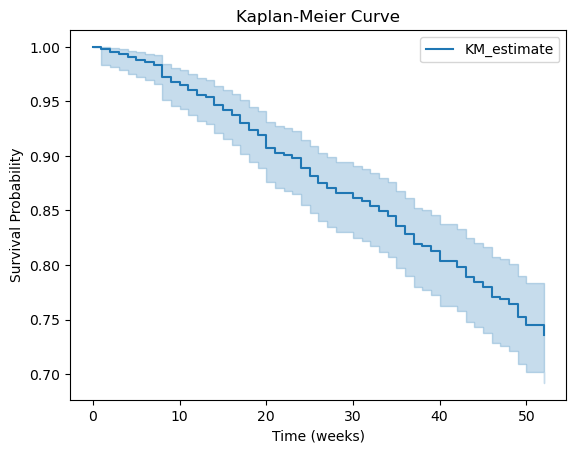

In [15]:
# Load the Rossi dataset
data = load_rossi()

# Fit the Kaplan-Meier estimator
kmf = KaplanMeierFitter()
kmf.fit(data['week'], event_observed=data['arrest'])

# Plot the Kaplan-Meier curve
kmf.plot_survival_function()
plt.title('Kaplan-Meier Curve')
plt.xlabel('Time (weeks)')
plt.ylabel('Survival Probability')
plt.show()


### Questions for Exploration

1. What happens to the Kaplan-Meier curves if you stratify the data by different covariates?
2. How can you extract median survival time from a Kaplan-Meier estimator in `lifelines`?
3. How do confidence intervals impact the interpretation of Kaplan-Meier curves?
4. How can you compare multiple survival groups using statistical tests such as the log-rank test? HINT: check this [link](https://lifelines.readthedocs.io/en/latest/lifelines.statistics.html).

In [16]:
KaplanMeierFitter?

Init signature: KaplanMeierFitter(alpha: 'float' = 0.05, label: 'str' = None)
Docstring:     
Class for fitting the Kaplan-Meier estimate for the survival function.

Parameters
----------
alpha: float, optional (default=0.05)
    The alpha value associated with the confidence intervals.
label: string, optional
    Provide a new label for the estimate - useful if looking at many groups.

Examples
--------
.. code:: python

    from lifelines import KaplanMeierFitter
    from lifelines.datasets import load_waltons
    waltons = load_waltons()

    kmf = KaplanMeierFitter(label="waltons_data")
    kmf.fit(waltons['T'], waltons['E'])
    kmf.plot()


Attributes
----------
survival_function_ : DataFrame
    The estimated survival function (with custom timeline if provided)
median_survival_time_ : float
    The estimated median time to event. np.inf if doesn't exist.
confidence_interval_ : DataFrame
    The lower and upper confidence intervals for the survival function. An alias of
    ``con

In [18]:
import sys
sys.path.append('../Lab Utils')
import utils
utils.testing()

This is a test function. Let's see if the updates stick!


## 3. Dataset Usage

On Blackboard, you'll find a folder titled 'NSCLC Dataset'. In here, you'll find two spreadsheets:
- `tpm_counts.csv` which contains RNA sequencing data in transcripts per million (TPM);
- `clinical.csv` which contains the associated clinical data for the study.

In [19]:
# IMPORTS
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE
import umap

# update to relative paths - note for future Caryn
rna = pd.read_csv('../Lab 5/NSCLC Data/tpm_counts.csv')
clinical = pd.read_csv('../Lab 5/NSCLC Data/clinical.csv')

/Users/caryngeady/Documents/GitHub/BINF-5507-Winter-2026/.pixi/envs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
from utils import clean_nsclc_rna

cleaned_rna, usubjid_rna = clean_nsclc_rna(rna.copy(), threshold_to_remove_column=0.7, n_neighbors=10)


In [21]:
# 3. Isolate the clinical data that we actually have sequencing for
clinical_subset = clinical[clinical['Case ID'].isin(usubjid_rna)]
print(clinical_subset.columns)

Index(['Case ID', 'Patient affiliation', 'Age at Histological Diagnosis',
       'Weight (lbs)', 'Gender', 'Ethnicity', 'Smoking status', 'Pack Years',
       'Quit Smoking Year', '%GG', 'Tumor Location (choice=RUL)',
       'Tumor Location (choice=RML)', 'Tumor Location (choice=RLL)',
       'Tumor Location (choice=LUL)', 'Tumor Location (choice=LLL)',
       'Tumor Location (choice=L Lingula)', 'Tumor Location (choice=Unknown)',
       'Histology ', 'Pathological T stage', 'Pathological N stage',
       'Pathological M stage', 'Histopathological Grade',
       'Lymphovascular invasion',
       'Pleural invasion (elastic, visceral, or parietal)',
       'EGFR mutation status', 'KRAS mutation status',
       'ALK translocation status', 'Adjuvant Treatment', 'Chemotherapy',
       'Radiation', 'Recurrence', 'Recurrence Location', 'Date of Recurrence',
       'Date of Last Known Alive', 'Survival Status', 'Date of Death',
       'Time to Death (days)', 'CT Date', 'Days between CT and sur

Recall that we are looking for two different formats on the data that we use for modeling. 
1. `lifelines` can take in a dataframe and you just need to point to the duration and event columns, respectively (yay!)
2. `sksurv` requires you to separate the features (`X`, conventionally) from the target (`y`, conventionally) --> moreover, `y` needs to be a tuple array, as above.

The way that the data is represented in the `clinical` and `clinical_subset` dataframes, we will need to derive the time/duration column. It is **NOT** directly given. What we need to do:
1. Create a `time` column by calculating the number of days between **'Date of Last Known Alive'** and **'CT Date'** (both in MM/DD/YYYY format).
2. Convert the **'Survival Status'** column into a boolean event indicator, where **Death** corresponds to `True` (event observed).

In [22]:
import pandas as pd
from datetime import datetime
import numpy as np
from sksurv.util import Surv

clinical_data = clinical.copy()

# Convert date columns to datetime format
clinical_data["Date of Last Known Alive"] = pd.to_datetime(clinical_data["Date of Last Known Alive"], format="%m/%d/%Y")
clinical_data["CT Date"] = pd.to_datetime(clinical_data["CT Date"], format="%m/%d/%Y")

# Calculate time in days
clinical_data["time"] = (clinical_data["Date of Last Known Alive"] - clinical_data["CT Date"]).dt.days - clinical_data['Days between CT and surgery']

# Convert event column to boolean (Death = True, Alive = False)
clinical_data["event"] = clinical_data["Survival Status"].apply(lambda x: True if x == "Death" else False)

# Convert to sksurv structured array format
survival_data = Surv.from_dataframe("event", "time", clinical_data)

## Extensions

Explore other survival analysis techniques such as:
- Accelerated Failure Time (AFT) models
- Competing risks models
- Time-dependent covariates in Cox regression

Compare their performance and interpretation with the techniques covered in this lab.